In [5]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

from math import comb
from matplotlib.colors import ListedColormap

sp.init_printing()


1.1 
найти: общее решение 

In [6]:
A = sp.Matrix([
    [1,  5, -2,  0],
    [-3, 1,  9, -5],
    [4, -8, -1,  7]
])

b = sp.Matrix([-7, 9, 0])

A_b = A.row_join(b)

rref_matrix, pivot_columns = A_b.rref()

print("RREF:")
display(rref_matrix)
print("Ведущие столбцы:", pivot_columns)

x1, x2, x3, x4 = sp.symbols('x1 x2 x3 x4')

print("Общее решение:")
display(sp.linsolve((A, b), (x1, x2, x3, x4)))


RREF:


⎡1  0  0  8/7   -11/7⎤
⎢                    ⎥
⎢0  1  0  -2/7  -6/7 ⎥
⎢                    ⎥
⎣0  0  1  -1/7   4/7 ⎦

Ведущие столбцы: (0, 1, 2)
Общее решение:


1.2 
найти: RREF и общее решение

In [7]:
A = sp.Matrix([
    [5, -1, 5, 9, -2],
    [3,  0, 6, 9, -1],
    [2,  0, 4, 6, -1]
])

b = sp.Matrix([-3, 4, 0])

A_b = A.row_join(b)

rref_matrix, pivot_columns = A_b.rref()

print("RREF:")
display(rref_matrix)
print("Ведущие столбцы:", pivot_columns)

x1, x2, x3, x4, x5 = sp.symbols('x1 x2 x3 x4 x5')

print("Общее решение:")
display(sp.linsolve((A, b), (x1, x2, x3, x4, x5)))


RREF:


⎡1  0  2  3  0  4⎤
⎢                ⎥
⎢0  1  5  6  0  7⎥
⎢                ⎥
⎣0  0  0  0  1  8⎦

Ведущие столбцы: (0, 1, 4)
Общее решение:


1.3 
найти: константы a и b

In [8]:
x, y, z, u = sp.symbols('x y z u')

A = sp.Matrix([
    [32, 97, 90, 48],
    [35, 84, 91, 54],
    [17, 18, 21, 13]
])

b = sp.Matrix([47, 40, 37])

solution = next(iter(sp.linsolve((A, b), (x, y, z, u))))
display(solution)

# Выражаем u
u_from_x = sp.solve(sp.Eq(solution[0], x), u)[0]
display(u_from_x)

# Подставляем его в выражение для y
y_function = sp.expand(solution[1].subs(u, u_from_x))
display(y_function)

a = y_function.subs(x, 0)
b = y_function.coeff(x)

print("y(x) =", y_function)
print("a =", a)
print("b =", b)


y(x) = 14027 - 4262*x
a = 14027
b = -4262


1.4

In [9]:
A = sp.Matrix([
    [3, 0, 2],
    [0, 1, 3],
    [2, 2, 0],
    [0, 1, 0]
])

B = sp.Matrix([
    [ 1,  2, -1, 2],
    [-2, -1,  1, 2],
    [ 2,  1,  1, 2]
])

C = sp.Matrix([
    [0, -4,  6,  1],
    [2,  2, -5, -2],
    [2, -2,  6,  4],
    [1,  3,  0,  1]
])

result = A * B + C
display(result)


⎡7   4  5   11⎤
⎢             ⎥
⎢6   4  -1  6 ⎥
⎢             ⎥
⎢0   0  6   12⎥
⎢             ⎥
⎣-1  2  1   3 ⎦

1.5
найти определители матриц

In [10]:
for n in range(1, 5):
    A = sp.Matrix([
        [min(i, j) for j in range(1, n + 1)]
        for i in range(1, n + 1)
    ])

    B = sp.Matrix([
        [max(i, j) for j in range(1, n + 1)]
        for i in range(1, n + 1)
    ])

    C = sp.Matrix([
        [abs(i - j) for j in range(1, n + 1)]
        for i in range(1, n + 1)
    ])

    print(
        f"n={n}: "
        f"det(A)={A.det()}, "
        f"det(B)={B.det()}, "
        f"det(C)={C.det()}"
    )



n=1: det(A)=1, det(B)=1, det(C)=0
n=2: det(A)=1, det(B)=-2, det(C)=-1
n=3: det(A)=1, det(B)=3, det(C)=4
n=4: det(A)=1, det(B)=-4, det(C)=-12


1.7
найти: определитель, след обратной матрицы 

In [11]:
n = 80000

d = np.linspace(0.99, 1.01, n)

a12 = 0.57
a21 = 0.03

det_2x2 = d[0] * d[1] - a12 * a21

det_A = det_2x2 * np.prod(d[2:])

trace_inv_A = (
    (d[0] + d[1]) / det_2x2 
    + np.sum(1 / d[2:])
)

print("Определитель A =", det_A)
print("След обратной матрицы =", trace_inv_A)


Определитель A = 0.25897911386522593
След обратной матрицы = 80002.702766086


1.8
найти: наименьший элемент матрицы B и сумму элементов матрицы B

In [12]:
n = 43000

# Диагональ геометрическая прогрессия
diagonal = np.geomspace(1, 1.07, n)

# Первая строка арифметическая прогрессия
first_row = np.linspace(1, 1.10, n)

# матрица диагональная, поэтому обратные элементы 1/a
inverse_diagonal = 1 / diagonal

inverse_first_row = -first_row[1:] / diagonal[1:]

min_element = min(
    inverse_diagonal.min(),
    inverse_first_row.min()
)

sum_elements = (
    inverse_diagonal.sum()
    + inverse_first_row.sum()
)

print("Наименьший элемент B =", min_element)
print("Сумма элементов B =", sum_elements)


Наименьший элемент B = -1.0280373831775702
Сумма элементов B = -2054.438267008656


1.10
найти: значение коэффов a и b

In [13]:
x = sp.symbols('x')

M = sp.Matrix([
    [7, 5, 5, x],
    [2, 2, 6, 9],
    [3, x, 8, 0],
    [3, 1, 1, 0]
])

det_M = sp.expand(M.det())

print("det(M) =", det_M)
print("a =", det_M.coeff(x, 2))
print("b =", det_M.coeff(x, 1))


det(M) = 16*x**2 - 116*x + 576
a = 16
b = -116


1.11 
найти: биномиальные коэффициенты по модулю 2

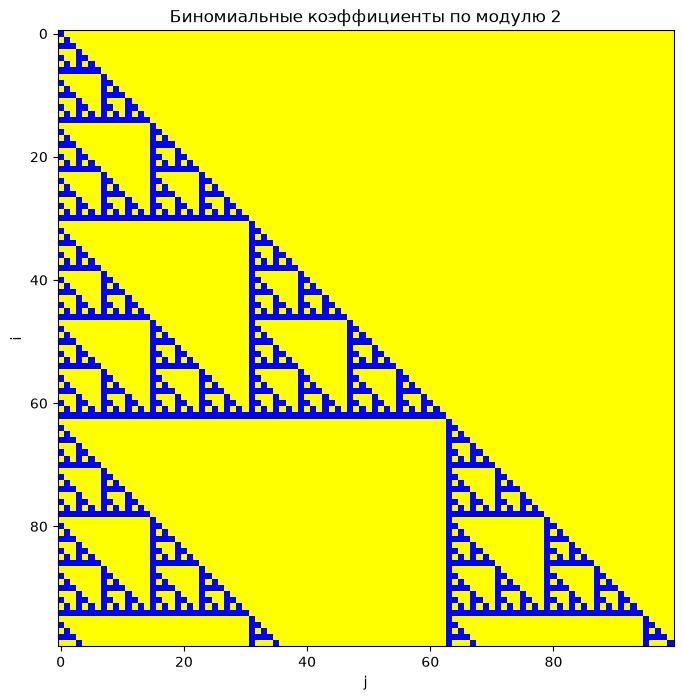

In [14]:
n = 100

A = np.zeros((n, n))

for i in range(1, n + 1):
    for j in range(1, i + 1):
        A[i - 1, j - 1] = comb(i, j) % 2

cmap = ListedColormap(["yellow", "blue"])

plt.figure(figsize=(8, 8))
plt.imshow(A, cmap=cmap)
plt.title("Биномиальные коэффициенты по модулю 2")
plt.xlabel("j")
plt.ylabel("i")
plt.show()


1.12
Матрица Адамара

H1:
[[1]]

H2:
[[ 1  1]
 [ 1 -1]]

H4:
[[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]

Проверка H4 = H2 ⊗ H2:
True

Проверка H64 = H2 ⊗ H32:
True


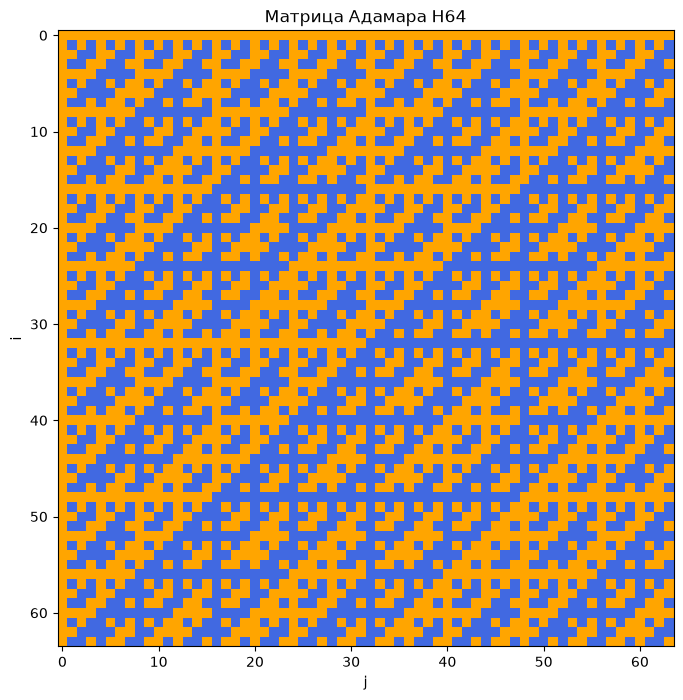

In [15]:
def hadamard_matrix(k):
    if k == 0:
        return np.array([[1]])

    H = hadamard_matrix(k - 1)

    return np.block([
        [H,  H],
        [H, -H]
    ])

H1 = hadamard_matrix(0)
H2 = hadamard_matrix(1)
H4 = hadamard_matrix(2)

print("H1:")
print(H1)

print("\nH2:")
print(H2)

print("\nH4:")
print(H4)

print("\nПроверка H4 = H2 ⊗ H2:")
print(np.array_equal(H4, np.kron(H2, H2)))

H64 = hadamard_matrix(6)

print("\nПроверка H64 = H2 ⊗ H32:")
print(np.array_equal(H64, np.kron(H2, hadamard_matrix(5))))

# Отрицательный элемент -> синий, положительный -> оранжевый
picture = (H64 > 0).astype(int)
cmap = ListedColormap(["royalblue", "orange"])

plt.figure(figsize=(8, 8))
plt.imshow(picture, cmap=cmap)
plt.title("Матрица Адамара H64")
plt.xlabel("j")
plt.ylabel("i")
plt.show()


1.13
Собственные значения и собственный вектор

In [16]:
A = np.array([
    [14, 10, 21],
    [12, 15, 26],
    [18, 11, 27]
])

eigenvalues, eigenvectors = np.linalg.eig(A)

# берём мнимые части и находим максимальную, беря её индек 
index = np.argmax(eigenvalues.imag)

Z = eigenvalues[index]
X = eigenvectors[:, index]

# Нормируем вектор: первая координата должна стать равной 1
X = X / X[0]

print("Z =", Z)
print("X =", X)
print("Im(Z) =", Z.imag)
print("Re(U) =", X[1].real)


Z = (1.9688403308016509+0.34478934842714026j)
X = [ 1.        +1.64958971e-17j  3.74781973+1.33084677e+00j
 -2.35758843-6.17318019e-01j]
Im(Z) = 0.34478934842714026
Re(U) = 3.747819729394882


1.14
найти: минимальный многочлен

In [17]:
x = sp.symbols('x')

A = sp.Matrix([
    [-3,  7,  -6, -1,  8, -3, -2],
    [ 1, -5,   8, -3, -5,  4, -5],
    [ 1,  3,  -4,  6, -2,  0,  8],
    [-1, 11, -12,  9,  3, -3,  9],
    [-3, 11, -12,  5,  8, -4,  6],
    [-3,  2,   1, -4,  4,  1, -7],
    [ 1, -5,   6, -2, -4,  3, -2]
])

char_poly = sp.factor(A.charpoly(x).as_expr())

print("Характеристический многочлен:")
display(char_poly)

I = sp.eye(7)

minimal_polynomial = None

for p in range(0, 4):
    for q in range(0, 5):
        if p + q == 0:
            continue

        P = (A ** p) * ((A - I) ** q)

        if P == sp.zeros(7):
            minimal_polynomial = sp.expand(x**p * (x - 1)**q)
            break

    if minimal_polynomial is not None:
        break

print("Минимальный многочлен:")
display(sp.factor(minimal_polynomial))


Характеристический многочлен:


Минимальный многочлен:


1.15 
найти: собственный ортонормированный базис и матрицу в этом базисе

In [18]:
A = sp.Matrix([
    [17, -8,  4],
    [-8, 17, -4],
    [ 4, -4, 11]
])

print("Собственные значения и собственные векторы:")
for value, multiplicity, vectors in A.eigenvects():
    print("lambda =", value)
    for vector in vectors:
        display(vector)

e1 = sp.Matrix([1, 1, 0]) / sp.sqrt(2)

v2 = sp.Matrix([-sp.Rational(1, 2), 0, 1])
v2 = v2 - v2.dot(e1) * e1
e2 = v2 / sp.sqrt(v2.dot(v2))

e3 = sp.Matrix([2, -2, 1]) / 3

P = sp.Matrix.hstack(e1, e2, e3)

print("Ортонормированный базис:")
display(P)

print("Проверка P^T P:")
display((P.T * P))

print("Матрица оператора в новом базисе:")
display((P.T * A * P))


Собственные значения и собственные векторы:
lambda = 9


⎡1⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣0⎦

⎡-1/2⎤
⎢    ⎥
⎢ 0  ⎥
⎢    ⎥
⎣ 1  ⎦

lambda = 27


⎡2 ⎤
⎢  ⎥
⎢-2⎥
⎢  ⎥
⎣1 ⎦

Ортонормированный базис:


⎡√2  -√2       ⎤
⎢──  ────  2/3 ⎥
⎢2    6        ⎥
⎢              ⎥
⎢√2   √2       ⎥
⎢──   ──   -2/3⎥
⎢2    6        ⎥
⎢              ⎥
⎢    2⋅√2      ⎥
⎢0   ────  1/3 ⎥
⎣     3        ⎦

Проверка P^T P:


⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

Матрица оператора в новом базисе:


⎡9  0  0 ⎤
⎢        ⎥
⎢0  9  0 ⎥
⎢        ⎥
⎣0  0  27⎦

1.16 
найти: ортогональное преобразование

In [19]:
A = sp.Matrix([
    [3,  4,  0,  0],
    [4, -3,  0,  0],
    [0,  0,  4, -2],
    [0,  0, -2,  1]
])

e1 = sp.Matrix([2, 1, 0, 0]) / sp.sqrt(5)
e2 = sp.Matrix([0, 0, 2, -1]) / sp.sqrt(5)
e3 = sp.Matrix([1, -2, 0, 0]) / sp.sqrt(5)
e4 = sp.Matrix([0, 0, 1, 2]) / sp.sqrt(5)

P = sp.Matrix.hstack(e1, e2, e3, e4)

D = (P.T * A * P)

print("Ортогональная матрица P:")
display(P)

print("Проверка P^T P:")
display((P.T * P))

print("Диагональная матрица D:")
display(D)

print("Канонический вид:")
print("f = 5*y1^2 + 5*y2^2 - 5*y3^2")


Ортогональная матрица P:


⎡2⋅√5          √5        ⎤
⎢────   0      ──     0  ⎥
⎢ 5            5         ⎥
⎢                        ⎥
⎢ √5         -2⋅√5       ⎥
⎢ ──    0    ──────   0  ⎥
⎢ 5            5         ⎥
⎢                        ⎥
⎢      2⋅√5           √5 ⎥
⎢ 0    ────    0      ── ⎥
⎢       5             5  ⎥
⎢                        ⎥
⎢      -√5           2⋅√5⎥
⎢ 0    ────    0     ────⎥
⎣       5             5  ⎦

Проверка P^T P:


⎡1  0  0  0⎤
⎢          ⎥
⎢0  1  0  0⎥
⎢          ⎥
⎢0  0  1  0⎥
⎢          ⎥
⎣0  0  0  1⎦

Диагональная матрица D:


⎡5  0  0   0⎤
⎢           ⎥
⎢0  5  0   0⎥
⎢           ⎥
⎢0  0  -5  0⎥
⎢           ⎥
⎣0  0  0   0⎦

Канонический вид:
f = 5*y1^2 + 5*y2^2 - 5*y3^2


1.17 
найти: тип кривой второго порядка, её каноническое уравнение и найдите каноническую систему координат

In [20]:
x, y, u, v = sp.symbols('x y u v')

# a)
center_a = sp.Matrix([2, 3])

P_a = sp.Matrix.hstack(
    sp.Matrix([-2, 1]) / sp.sqrt(5),
    sp.Matrix([1, 2]) / sp.sqrt(5)
)

expr_a = 5*x**2 + 4*x*y + 8*y**2 - 32*x - 56*y + 80

x_a = center_a[0] + P_a[0, 0]*u + P_a[0, 1]*v
y_a = center_a[1] + P_a[1, 0]*u + P_a[1, 1]*v

canonical_a = sp.expand(expr_a.subs({x: x_a, y: y_a}))

print("1.17 a)")
print("Новое уравнение:")
display(canonical_a)
print("Тип: эллипс")
print("Канонический вид: u^2/9 + v^2/4 = 1")

# б) 
center_b = sp.Matrix([1, 1])

P_b = sp.Matrix.hstack(
    sp.Matrix([-2, 3]) / sp.sqrt(13),
    sp.Matrix([3, 2]) / sp.sqrt(13)
)

expr_b = 5*x**2 + 12*x*y - 22*x - 12*y - 19

x_b = center_b[0] + P_b[0, 0]*u + P_b[0, 1]*v
y_b = center_b[1] + P_b[1, 0]*u + P_b[1, 1]*v

canonical_b = sp.expand(expr_b.subs({x: x_b, y: y_b}))

print("\n1.17 б)")
print("Новое уравнение:")
display(canonical_b)
print("Тип: гипербола")
print("Канонический вид: v^2/4 - u^2/9 = 1")


1.17 a)
Новое уравнение:


Тип: эллипс
Канонический вид: u^2/9 + v^2/4 = 1

1.17 б)
Новое уравнение:


Тип: гипербола
Канонический вид: v^2/4 - u^2/9 = 1


1.18

In [21]:
lam = sp.symbols('lambda', real=True)

A = sp.Matrix([
    [1,   lam, 5],
    [lam, 4,   3],
    [5,   3,   1]
])

delta1 = A[:1, :1].det()
delta2 = A[:2, :2].det()
delta3 = A.det()

print("Delta1 =", delta1)
print("Delta2 =", sp.factor(delta2))
print("Delta3 =", sp.factor(delta3))

roots = sp.solve(sp.Eq(delta3, 0), lam)

print("\nКорни Delta3 = 0:")
for root in roots:
    print(root, "≈", sp.N(root))

print("\nПо критерию Сильвестра нужно:")
print("Delta1 > 0")
print("Delta2 > 0 -> |lambda| < 2")
print("Delta3 > 0 -> 15 - 2*sqrt(30) < lambda < 15 + 2*sqrt(30)")
print("Пересечения нет.")


Delta1 = 1
Delta2 = -(lambda - 2)*(lambda + 2)
Delta3 = -lambda**2 + 30*lambda - 105

Корни Delta3 = 0:
15 - 2*sqrt(30) ≈ 4.04554884989668
2*sqrt(30) + 15 ≈ 25.9544511501033

По критерию Сильвестра нужно:
Delta1 > 0
Delta2 > 0 -> |lambda| < 2
Delta3 > 0 -> 15 - 2*sqrt(30) < lambda < 15 + 2*sqrt(30)
Пересечения нет.


1.19


In [22]:
lam = sp.symbols('lambda', real=True)

A = sp.Matrix([
    [lam,  1, -1],
    [1,   -2,  1],
    [-1,   1, -3]
])

delta1 = A[:1, :1].det()
delta2 = A[:2, :2].det()
delta3 = A.det()

print("Delta1 =", delta1)
print("Delta2 =", sp.factor(delta2))
print("Delta3 =", sp.factor(delta3))

print("\nДля отрицательной определённости:")
print("Delta1 < 0")
print("Delta2 > 0")
print("Delta3 < 0")
print("Ответ: lambda < -3/5")


Delta1 = lambda
Delta2 = -2*lambda - 1
Delta3 = 5*lambda + 3

Для отрицательной определённости:
Delta1 < 0
Delta2 > 0
Delta3 < 0
Ответ: lambda < -3/5


1.20 
найти: эквивалентны ли Q1 Q2

In [23]:
Q1 = sp.Matrix([
    [ 2,  4, -2],
    [ 4,  9, -5],
    [-2, -5,  3]
])

Q2 = sp.Matrix([
    [ 2, -2, -2],
    [-2,  3,  4],
    [-2,  4,  6]
])

print("Собственные значения Q1:")
display(Q1.eigenvals())

print("Собственные значения Q2:")
display(Q2.eigenvals())

def inertia(matrix):
    eigenvalues = np.linalg.eigvalsh(np.array(matrix, dtype=float))

    positive = np.sum(eigenvalues > 1e-9)
    negative = np.sum(eigenvalues < -1e-9)
    zero = len(eigenvalues) - positive - negative

    return int(positive), int(negative), int(zero)

print("Инерция Q1 =", inertia(Q1))
print("Инерция Q2 =", inertia(Q2))

print("Формы эквивалентны над R, так как их инерции совпадают.")


Собственные значения Q1:


Собственные значения Q2:


Инерция Q1 = (2, 0, 1)
Инерция Q2 = (2, 0, 1)
Формы эквивалентны над R, так как их инерции совпадают.
